Desenvolvimento de modelos em visão computacional

Pré-processamento de dados 

Essa fase envolve a preparação e limpeza dos dados antes de serem alimentados no modelo. No contexto
das CNNs, pré-processamento muitas vezes inclui:

> Redimensionamento das imagens para um tamanho específico.
> Normalização dos valores de pixel para um intervalo predefinido.
> Possível ampliação dos dados para aumentar a diversidade do conjunto de treinamento.

Além disso, pode envolver:

> Segmentação de regiões de interesse nas imagens.
> Remoção de ruídos ou artefatos indesejados.
> Outras técnicas para melhorar a qualidade e utilidade dos dados para o modelo.

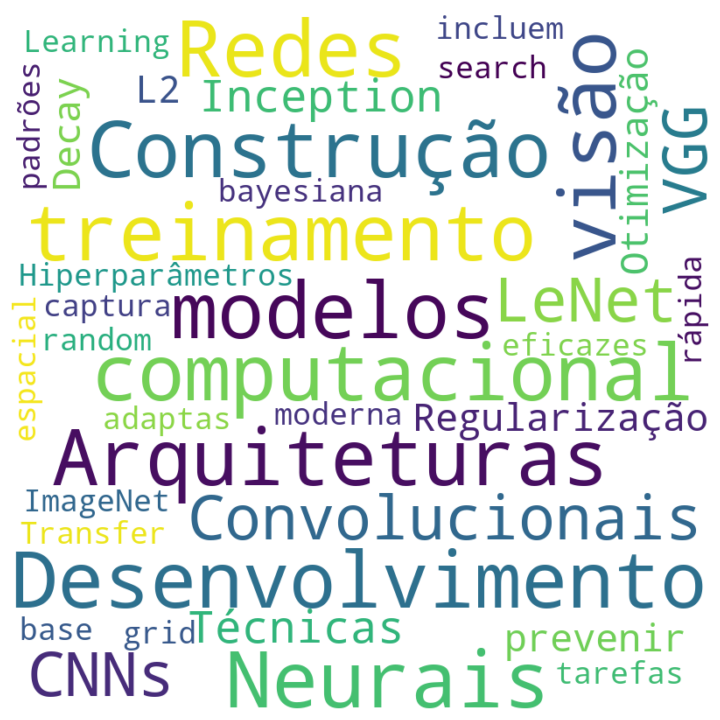

In [4]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Texto com as palavras-chave extraídas da imagem
texto = """
--> Desenvolvimento modelos visão computacional Construção treinamento
--> Arquiteturas Redes Neurais Convolucionais CNNs LeNet VGG Inception
--> Técnicas Regularização L2 Decay prevenir
--> Otimização Hiperparâmetros search random bayesiana grid
--> Transfer Learning ImageNet base adaptas tarefas eficazes
--> incluem captura espacial padrões rápida moderna
"""

wordcloud = WordCloud(
    width=800, 
    height=800, 
    background_color='white', 
    colormap='viridis',
    min_font_size=10
).generate(texto)

plt.figure(figsize=(7, 7), facecolor=None)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

# Reconhecimento e classificação de objetos

É uma das tarefas mais comuns e importantes da visão computacional. Utilizando técnicas como as CNNs, os sistemas são treinados para identificar e classificar objetos em imagens, atribuindo-lhes rótulos ou categorias específicas. Essa capacidade é muito aplicada em diversas áreas, como sistemas de segurança, controle de qualidade industrial, assistência médica, entre outros.

Por exemplo, em um sistema de monitoramento de tráfego, as CNNs podem ser usadas para reconhecer e classificar diferentes tipos de veículos em tempo real. Um exemplo numérico seria a classificação de imagens de diferentes raças de cães em um conjunto de dados de teste, no qual a CNN atribui corretamente o rótulo de cada raça com alta precisão.

Como podemos perceber, as redes neurais convolucionais têm sido uma ferramenta poderosa para análise e interpretação de imagens em diversas aplicações do mundo real, desde a extração de características até o reconhecimento e a classificação de objetos.


image 1/1 c:\Users\leona\Downloads\IA-aplicada-visao-computacional\Fundamentos da inteligncia artificial\transito.jpg: 384x640 2 persons, 21 cars, 1 bus, 1 truck, 45.2ms
Speed: 1.5ms preprocess, 45.2ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)


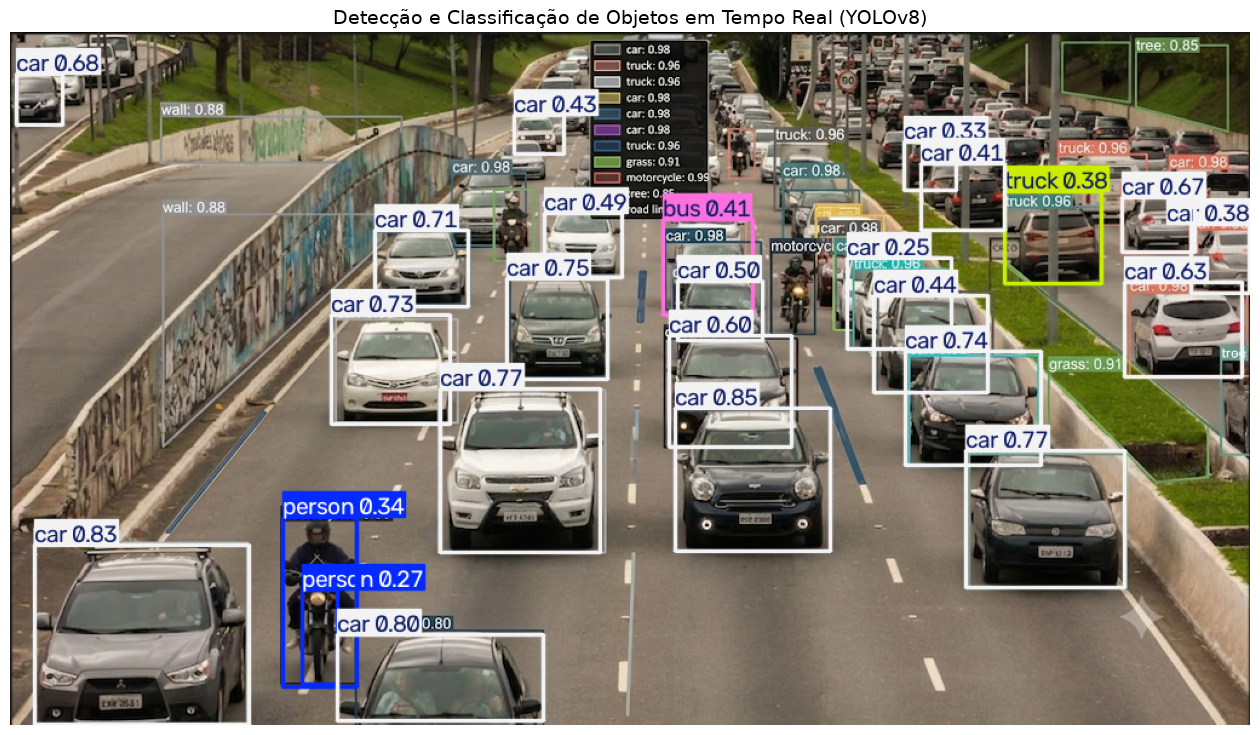


--- RESUMO DE CARROS DETECTADOS PELA IA ---
- Car: 21 identificado(s)
- Bus: 1 identificado(s)
- Truck: 1 identificado(s)
- Person: 2 identificado(s)


In [18]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

modelo = YOLO("yolov8n.pt")

caminho_imagem = "transito.jpg"

resultados = modelo(caminho_imagem, conf=0.25)

imagem_resultado_bgr = resultados[0].plot()

imagem_resultado_rgb = cv2.cvtColor(imagem_resultado_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 10))
plt.imshow(imagem_resultado_rgb)
plt.title("Detecção e Classificação de Objetos em Tempo Real (YOLOv8)", fontsize=14)
plt.axis("off")
plt.show()

print("\n--- RESUMO DE CARROS DETECTADOS PELA IA ---")
classes_detectadas = resultados[0].boxes.cls.tolist()
nomes_classes = resultados[0].names

contagem = {}
for cls_id in classes_detectadas:
    nome = nomes_classes[int(cls_id)]
    contagem[nome] = contagem.get(nome, 0) + 1

for objeto, qtd in contagem.items():
    print(f"- {objeto.capitalize()}: {qtd} identificado(s)")

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Fazer previsões no conjunto de teste
predictions = model.predict(test_images)

# 2. Converter probabilidades em rótulos (pega a classe com maior probabilidade)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(test_labels, axis=1)

# 3. Calcular a matriz de confusão
confusion_matrix = tf.math.confusion_matrix(labels=true_labels, predictions=predicted_labels)

# 4. Plotar a matriz de confusão como um gráfico de calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='viridis')  # Paleta 'viridis' fica excelente!
plt.xlabel('Classe Predita', fontsize=12)
plt.ylabel('Classe Verdadeira', fontsize=12)
plt.title('Matriz de Confusão - Desempenho do Modelo CNN', fontsize=14)
plt.show()


ModuleNotFoundError: No module named 'tensorflow'

Animation size has reached 21240527 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


Animação salva em: treino_animado.gif


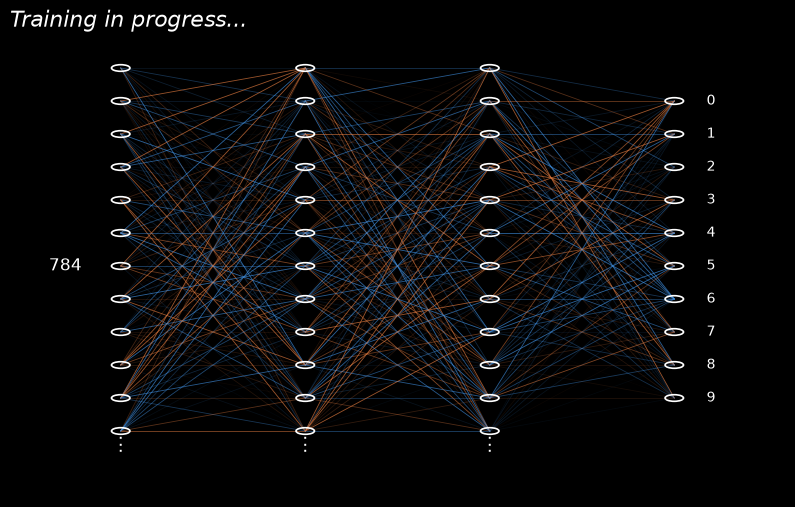

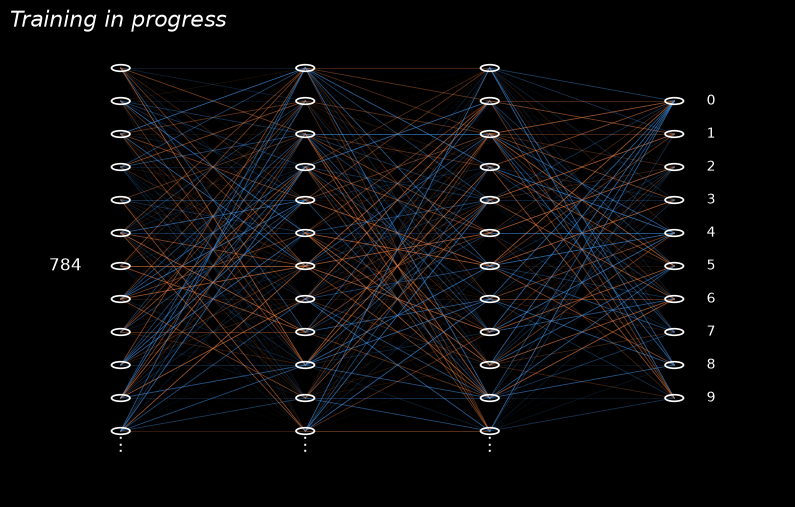

: 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

def build_layer_positions(layer_sizes, max_neurons_shown=12):
    v_spacing = 1.0
    h_spacing = 2.0
    display_sizes = [min(n, max_neurons_shown) for n in layer_sizes]
    max_display = max(display_sizes)
    layer_positions = []
    for i, n_show in enumerate(display_sizes):
        x = i * h_spacing
        top = (max_display * v_spacing) / 2
        ys = [top - j * v_spacing for j in range(n_show)]
        offset = (max_display - n_show) * v_spacing / 2
        ys = [y - offset for y in ys]
        layer_positions.append(list(zip([x] * n_show, ys)))
    return layer_positions, max_display, display_sizes


def animate_neural_net(layer_sizes, layer_labels=None, max_neurons_shown=12,
                        n_frames=60, interval=80, save_path=None):
    
    layer_positions, max_display, display_sizes = build_layer_positions(layer_sizes, max_neurons_shown)

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('black')
    ax.set_facecolor('black')

    rng = np.random.default_rng(42)
    lines = []
    line_data = []  
    for i in range(len(layer_positions) - 1):
        for x1, y1 in layer_positions[i]:
            for x2, y2 in layer_positions[i + 1]:
                base_w = rng.uniform(-1, 1)
                phase = rng.uniform(0, 2 * np.pi)
                speed = rng.uniform(0.15, 0.35)
                line, = ax.plot([x1, x2], [y1, y2], linewidth=0.6, zorder=1)
                lines.append(line)
                line_data.append((base_w, phase, speed))

    for i, layer in enumerate(layer_positions):
        for x_, y_ in layer:
            circle = plt.Circle((x_, y_), 0.1, color='white', fill=False, linewidth=1.2, zorder=4)
            ax.add_patch(circle)
        if layer_sizes[i] > display_sizes[i]:
            x = layer[0][0]
            ax.text(x, min(y for _, y in layer) - 0.6, '⋮', color='white', fontsize=14, ha='center')
        if i == 0:
            ax.text(layer[0][0] - 0.6, 0, str(layer_sizes[0]), color='white', fontsize=12,
                    ha='center', va='center')

    if layer_labels:
        for (x_, y_), label in zip(layer_positions[-1], layer_labels):
            ax.text(x_ + 0.35, y_, str(label), color='white', fontsize=10, va='center')

    title = ax.set_title('Training in progress...', color='white', fontsize=16, loc='left', style='italic')

    ax.set_xlim(-1.2, (len(layer_sizes) - 1) * 2.0 + 1.2)
    ax.set_ylim(-(max_display * 1.0) / 2 - 1, (max_display * 1.0) / 2 + 1)
    ax.axis('off')

    dots = ['', '.', '..', '...']

    def update(frame):
        for line, (base_w, phase, speed) in zip(lines, line_data):
            w = base_w * np.sin(frame * speed + phase)
            color = '#e07a3f' if w < 0 else '#3f8fe0'
            alpha = min(abs(w), 0.7)
            line.set_color(color)
            line.set_alpha(alpha)
        title.set_text('Training in progress' + dots[frame % 4])
        return lines + [title]

    ani = animation.FuncAnimation(fig, update, frames=n_frames, interval=interval, blit=False)

    if save_path:
        ani.save(save_path, writer='pillow', fps=1000 // interval)
        print(f'Animação salva em: {save_path}')

    return fig, ani


from IPython.display import HTML

fig, ani = animate_neural_net(
    layer_sizes=[784, 16, 16, 10],
    layer_labels=list(range(10))
)
HTML(ani.to_jshtml())
fig, ani = animate_neural_net(
    layer_sizes=[784, 16, 16, 10],
    layer_labels=list(range(10)),
    save_path='treino_animado.gif'
)